In [8]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [15]:
with open('horizon excursion/Deterministic_results_rota_test.json') as json_file:
    F_results = json.load(json_file)


In [24]:
# Search for both words in keys
# search_words = ['X', 'Rotavirus', 'Serum_Institute']
# result = {key: value for key, value in F_results.items() if all(word in key for word in search_words)}
# result

# Search for both words in keys, excluding keys with the word "tilda"
search_words = ["X", 'GSK', 'Rotavirus']
result = {key: value for key, value in F_results.items() if all(word in key for word in search_words)}
result

{'X_tilda[Rotavirus,GSK,(13, 15)]': 0.0,
 'X_tilda[Rotavirus,GSK,(4, 4)]': 0.0,
 'X[Rotavirus,GSK,12]': 0.0,
 'X_tilda[Rotavirus,GSK,(14, 14)]': 0.0,
 'X_tilda[Rotavirus,GSK,(4, 8)]': 0.0,
 'X_tilda[Rotavirus,GSK,(1, 1)]': 0.0,
 'X_tilda[Rotavirus,GSK,(8, 8)]': 0.0,
 'X[Rotavirus,GSK,15]': 0.0,
 'X_tilda[Rotavirus,GSK,(10, 10)]': 0.0,
 'X_tilda[Rotavirus,GSK,(6, 10)]': 0.0,
 'X_tilda[Rotavirus,GSK,(1, 3)]': 527922579.0105874,
 'X_tilda[Rotavirus,GSK,(11, 11)]': 0.0,
 'X_tilda[Rotavirus,GSK,(3, 7)]': 0.0,
 'X[Rotavirus,GSK,10]': 0.0,
 'X_tilda[Rotavirus,GSK,(3, 3)]': 0.0,
 'X_tilda[Rotavirus,GSK,(2, 2)]': 527922579.0105874,
 'X_tilda[Rotavirus,GSK,(6, 6)]': 0.0,
 'X_tilda[Rotavirus,GSK,(12, 12)]': 0.0,
 'X_tilda[Rotavirus,GSK,(10, 12)]': 0.0,
 'X[Rotavirus,GSK,6]': 0.0,
 'X[Rotavirus,GSK,13]': 0.0,
 'X[Rotavirus,GSK,8]': 0.0,
 'X_tilda[Rotavirus,GSK,(7, 9)]': 0.0,
 'X_tilda[Rotavirus,GSK,(9, 9)]': 0.0,
 'X_tilda[Rotavirus,GSK,(1, 5)]': 527922579.0105874,
 'X[Rotavirus,GSK,2]': 527922579

In [11]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [12]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


         Antigen  Year  Value
0    Hepatitis_B     3    0.0
1          Polio     6    0.0
2    Hepatitis_B     7    0.0
3        Rubella    14    0.0
4            HPV     8    0.0
..           ...   ...    ...
187    Pertussis     2    0.0
188      Measles     6    0.0
189      Tetanus     9    0.0
190        Mumps     9    0.0
191          PCV     7    0.0

[192 rows x 3 columns]


In [13]:
import pandas as pd

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Grouping and counting
result = df.groupby(['Antigen', 'Year'])['Value'].sum().reset_index()
result = result[result['Value'] != 0.0]

# Grouping by Antigen and summing the Value column
# result = df.groupby('Antigen')['Value'].sum().reset_index()

# Displaying the result
print(result)


         Antigen  Year         Value
17           HPV     1  1.797498e+07
18           HPV     2  1.971061e+07
19           HPV     3  4.651061e+07
20           HPV     4  1.173106e+08
21           HPV     5  2.083198e+08
33   Hepatitis_B     1  5.702800e+07
81         Mumps     1  9.977900e+06
97           PCV     1  6.466667e+06
98           PCV     2  1.103625e+06
99           PCV     3  2.028036e+08
129        Polio     1  2.819625e+08
145    Rotavirus     1  5.651060e+07


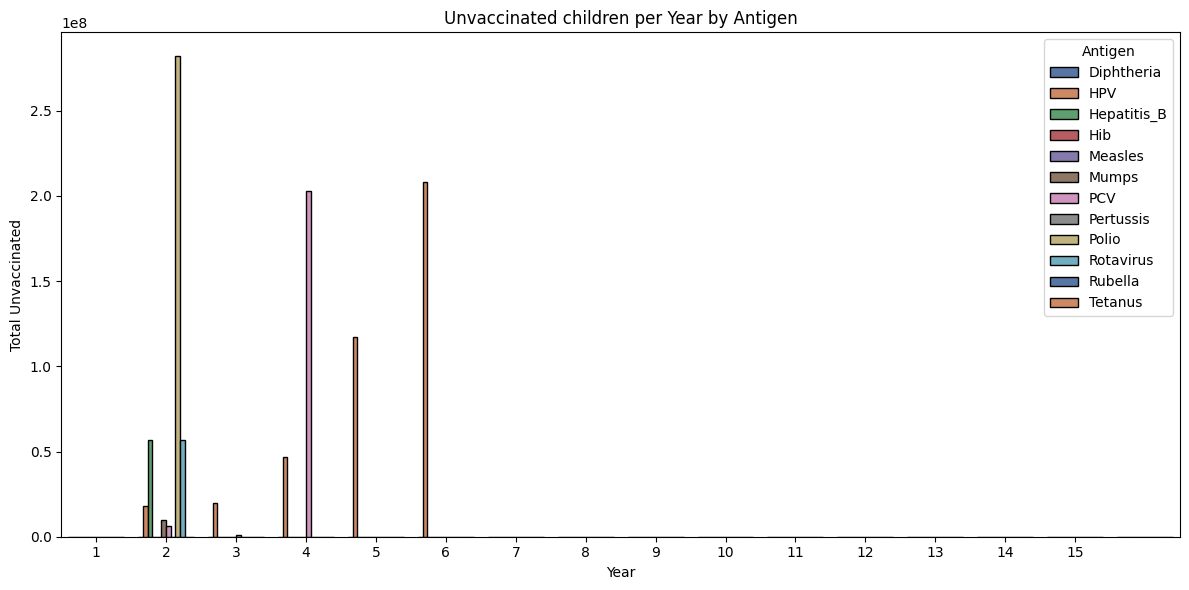

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 16))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Set a color palette with distinct colors for each antigen
palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout for better visualization
plt.savefig('Deterministic_results_modified_start_unvaccinated_children.png')
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 16))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Set a color palette with distinct colors for each antigen
palette = sns.color_palette("husl", n_colors=len(result['Antigen'].unique()))

# Plotting the bar chart with Plotly Express
fig = px.bar(result, x='Year', y='Value', color='Antigen', barmode='group', text='Value',
             labels={'Value': 'Total Unvaccinated'},
             title='Unvaccinated children per Year by Antigen',
             color_discrete_sequence=palette)

# Add black borders around each bar
fig.update_traces(marker_line_color='black', marker_line_width=1.5)

# Set x-axis ticks for all years
fig.update_xaxes(tickvals=list(range(len(all_years))), ticktext=all_years)

# Customize layout
fig.update_layout(xaxis_title='Year', yaxis_title='Total Unvaccinated', legend_title='Antigen', 
                  legend=dict(title='Antigen', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))

# Set a larger plot size
fig.update_layout(width=1000, height=500)

# Show the interactive plot
fig.show()


## Unvaccinated children without starting point

In [ ]:
with open('Deterministic_results.json') as json_file:
    Q_results_clean = json.load(json_file)

In [ ]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in Q_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

In [ ]:
grouped_results

In [ ]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.savefig('unvax_childred_without_start.png')
plt.show()
